# batch generate file tags for the cleaned documents

In [1]:
from utils.dify import FileUploadClient, WorkFlowRunClient
from tqdm import tqdm
from wordcloud import WordCloud
from collections import Counter

import os
import pathlib
import random
import shutil
import json
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [4]:
TAG_API_KEY = "app-oEOOvu6QpkAxa5VfABwqiTL0"
UPLOAD_FILE_URL = "http://10.26.58.108/v1/files/upload"
WORKFLOW_RUN_URL = "http://10.26.58.108/v1/workflows/run"
USER = "abc-123"

file_upload_client = FileUploadClient(
    api_key=TAG_API_KEY, base_url=UPLOAD_FILE_URL, user=USER
)
workflow_run_client = WorkFlowRunClient(
    api_key=TAG_API_KEY, base_url=WORKFLOW_RUN_URL, user=USER
)
tags_target_folder = "D:\\project\\SABRE-RAG\\data"
tags_files = os.listdir(tags_target_folder)

tags_list = []
for file_path in tqdm(
    tags_files,
    desc="Tagging papers",
    total=len(tags_files),
):
    file_path = os.path.join(tags_target_folder, file_path)
    # upload the file to the server
    file_upload_response = file_upload_client.request(file_path)

    # get the file upload id
    file_upload_id = file_upload_response.get("id")
    # run the workflow with the file upload id as input parameter
    workflow_run_response = workflow_run_client.request(
        param_name="input_file", upload_file_id=file_upload_id
    )

    # get the result
    result = workflow_run_response.get("data", {}).get("outputs", {}).get("result", {})
    print(result)
    tags_list.append(result)

# 保存成为 jsonl 文件
with open("papers_tag.jsonl", "w", encoding="utf-8") as f:
    for tag in tqdm(tags_list, desc="Saving papers tag"):
        f.write(json.dumps(tag, ensure_ascii=False) + "\n")

    print("Papers tag saved successfully.")

Tagging papers:   0%|          | 1/645 [00:24<4:23:07, 24.51s/it]

{'file_name': '0001.pdf', 'title': 'In situ NMR Observation of Tin Trichloride-Activated Rhodium Dihydride Complexes Using Parahydrogen Induced Polarization', 'method': '1H-PHIP'}


Tagging papers:   0%|          | 2/645 [00:47<4:10:49, 23.41s/it]

{'file_name': '0002.pdf', 'title': 'Parahydrogen-induced polarization in the presence of NMR shift reagents', 'method': '1H-PHIP'}


Tagging papers:   0%|          | 3/645 [01:14<4:29:09, 25.16s/it]

...

{'file_name': '0019.pdf', 'title': 'More Than 12% Polarization and 20 Minute Lifetime of 15N in a Choline Derivative Utilizing Parahydrogen and a Rhodium Nanocatalyst in Water', 'method': '15N-PHIP'}


Tagging papers:   3%|▎         | 20/645 [11:18<4:52:00, 28.03s/it]

{'file_name': '0020.pdf', 'title': 'Alkyne gem-Hydrogenation: Formation of Pianostool Ruthenium Carbene Complexes and Analysis of Their Chemical Character', 'method': '1H-PHIP'}


Tagging papers:   3%|▎         | 20/645 [11:44<6:07:03, 35.24s/it]


KeyboardInterrupt: 

In [ ]:
num_select = 200  # 选取数量
selected_200 = random.sample(paper_info_list, min(num_select, len(paper_info_list)))

selected_df = pd.DataFrame(selected_200)
selected_df['filename'] = selected_df['filename'].apply(lambda x: pathlib.Path(x).name)
selected_df.to_csv('selected_200.csv', index=False, columns=['filename'])

# Plot the distribution of the number of questions in each file

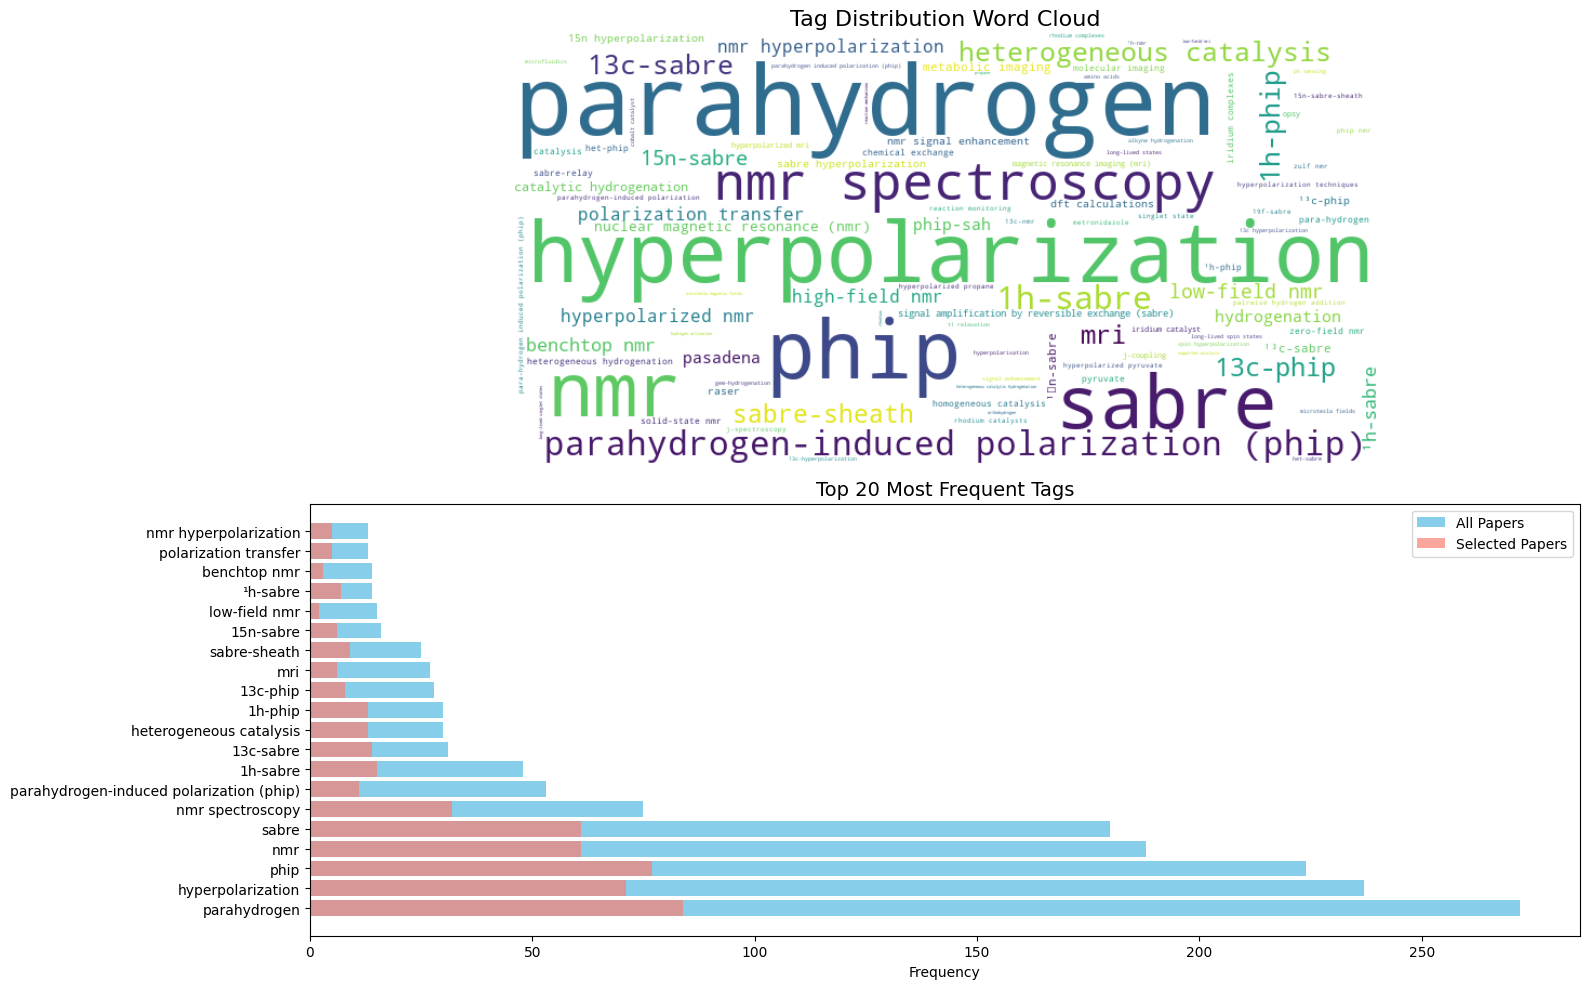

In [ ]:
def plot_tag_distribution(paper_info_list, selected_papers=None):
    """
    绘制文献标签分布图
    
    参数:
        paper_info_list: 所有文献信息列表
        selected_papers: (可选)已选中的文献列表，用于对比分析
    """
    # 1. 提取所有标签
    all_tags = [tag for paper in paper_info_list for tag in paper['tags']]
    
    # 2. 计算标签频率
    tag_counts = Counter(all_tags)
    
    # 3. 创建图表
    plt.figure(figsize=(16, 10))
    
    # 4. 词云图 - 展示所有标签分布
    plt.subplot(2, 1, 1)
    wordcloud = WordCloud(width=800, height=400, 
                          background_color='white',
                          colormap='viridis',
                          max_words=100).generate_from_frequencies(tag_counts)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title('Tag Distribution Word Cloud', fontsize=16)
    
    # 5. 条形图 - 展示前N个高频标签
    plt.subplot(2, 1, 2)
    
    # 获取前 20 个高频标签
    top_tags = tag_counts.most_common(20)
    tags, counts = zip(*top_tags)
    
    # 创建条形图
    y_pos = np.arange(len(tags))
    plt.barh(y_pos, counts, align='center', color='skyblue')
    plt.yticks(y_pos, tags)
    plt.xlabel('Frequency')
    plt.title('Top 20 Most Frequent Tags', fontsize=14)
    
    # 6. 如果有选中文献，添加对比信息
    if selected_papers:
        # 提取选中文献的标签
        selected_tags = [tag for paper in selected_papers for tag in paper['tags']]
        selected_counts = Counter(selected_tags)
        
        # 在条形图上添加选中文献的频率
        selected_freqs = [selected_counts.get(tag, 0) for tag in tags]
        plt.barh(y_pos, selected_freqs, align='center', color='salmon', alpha=0.7)
        
        # 添加图例
        plt.legend(['All Papers', 'Selected Papers'])
    
    plt.tight_layout()
    plt.show()

# 绘制所有文献标签分布图
plot_tag_distribution(paper_info_list, selected_200)

## Select files for constructing QAC dataset

In [76]:
selected_200_files = pd.read_csv('selected_200.csv')
selected_200_files = selected_200_files['filename'].to_list()

selected_filename = [
    os.path.splitext(os.path.basename(filename))[0] + '_cleaned'
    for filename in selected_200_files
]

print(selected_filename)

# get the cleaned files 
cleaned_files = os.listdir('./cleaned/')
cleaned_filename = [
    os.path.splitext(os.path.basename(filename))[0]
    for filename in cleaned_files
]

# 复制名字相同的文件到指定目录下
for filename in selected_filename:
    if filename in cleaned_filename:
        shutil.copyfile(
            os.path.join('./cleaned/', filename + '.md'),
            os.path.join('./qac_files/', filename + '.md')
        )

['10.1002_anie.201202967_cleaned', '10.1021_ac403653q_cleaned', '10.1021_jz501754j_cleaned', '10.1021_acs.analchem.7b01363_cleaned', '10.1021_jacs.6b08128_cleaned', '10.1515_pac-2020-0203_cleaned', '10.1021_acs.jpcc.9b04179_cleaned', '10.1021_jz402078h_cleaned', '10.1021_acs.jpca.5b06802_cleaned', '10.1021_acs.analchem.2c02160_cleaned', '10.1039_c6sc05276b_cleaned', '10.1039_d2ra01346k_cleaned', '10.1021_acs.jpclett.3c00707_cleaned', '10.1039_c9cp05227e_cleaned', '10.1039_d1cp02383g_cleaned', '10.1021_acs.jpcc.6b03267_cleaned', '10.1039_c7cy00252a_cleaned', '10.1021_acscatal.3c05378_cleaned', '10.3390_app9061173_cleaned', '10.1021_acs.analchem.9b00259_cleaned', '10.1002_cphc.201300595_cleaned', '10.1039_b908198d_cleaned', '10.1007_s00723-021-01348-9_cleaned', '10.1021_jacs.8b08614_cleaned', '10.1039_c9cc02186h_cleaned', '10.1039_c6ra15808k_cleaned', '10.1002_anie.202407349_cleaned', '10.1038_s41598-020-71282-6_cleaned', '10.1126_sciadv.ado0373_cleaned', '10.1134_S0012501615100073_clean

## Gernerate QAC dataset using batch processing

In [1]:
from utils.dify import FileUploadClient, WorkFlowRunClient
from tqdm import tqdm

import os

QAC_API_KEY = "app-cTze2py6WNLhGAq8Ls7dCcyj"
UPLOAD_FILE_URL = "http://localhost/v1/files/upload"
WORKFLOW_RUN_URL = "http://localhost/v1/workflows/run"
qac_target_folder = "D:\\project\\SABRE-RAG\\qac_files"
USER = "abc-123"

for file_path in tqdm(os.listdir(qac_target_folder)):
    file_upload_client = FileUploadClient(api_key=QAC_API_KEY, base_url=UPLOAD_FILE_URL, user=USER)
    workflow_run_client = WorkFlowRunClient(api_key=QAC_API_KEY, base_url=WORKFLOW_RUN_URL, user=USER)

    file_path = os.path.join(qac_target_folder, file_path)
    
    # upload the file to the server
    file_upload_response = file_upload_client.request(file_path)
    # get the file upload id
    file_upload_id = file_upload_response.get("id")
    # run the workflow with the file upload id as input parameter
    workflow_run_response = workflow_run_client.request(param_name="input_file", upload_file_id=file_upload_id)

100%|██████████| 164/164 [8:18:13<00:00, 182.28s/it]  
